First 5 rows:
   Calories  Total Fat  Saturated Fat  Monounsaturated Fat  \
0     149.0          0            0.0                  0.0   
1     123.0          0            0.0                  0.0   
2     150.0          0            0.0                  0.0   
3     110.0          0            0.0                  0.0   
4     143.0          0            0.0                  0.0   

   Polyunsaturated Fat  Trans Fat  Cholesterol  Sodium  Total Carbohydrate  \
0                  0.0        0.0            0     9.0                 9.8   
1                  0.0        0.0            0     5.0                 6.6   
2                  0.0        0.0            0     4.0                11.4   
3                  0.0        0.0            0     6.0                 7.0   
4                  0.0        0.0            0     7.0                13.1   

   Dietary Fiber  Sugars  Sugar Alcohol  Protein  Vitamin A  Vitamin C  \
0            0.0     0.0              0      1.3          0          0

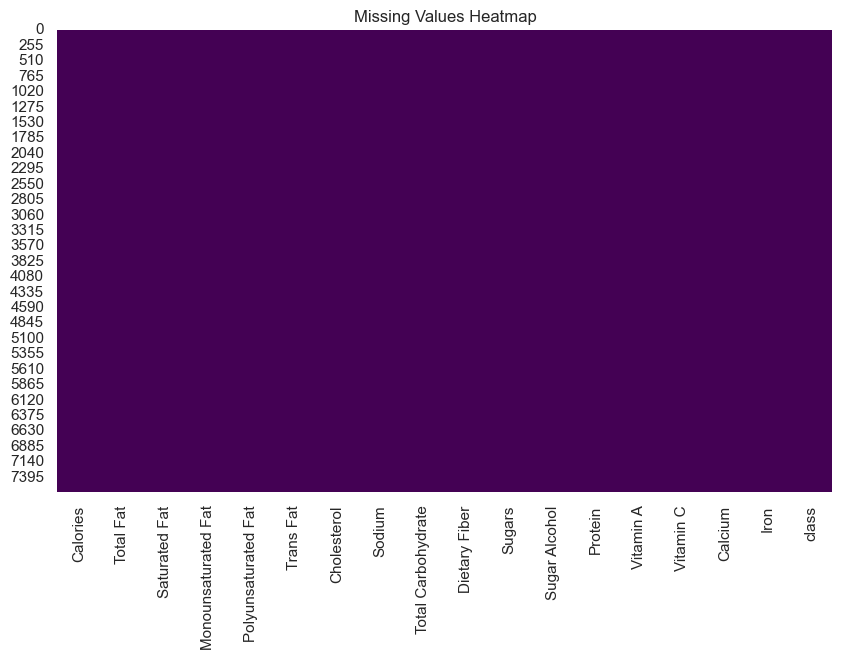


Statistical Summary:
          Calories    Total Fat  Saturated Fat  Monounsaturated Fat  \
count  7639.000000  7639.000000    7639.000000          7639.000000   
mean    105.098835     2.318235       0.368920             0.309216   
std      77.224368     3.438941       0.737164             1.310260   
min       0.000000     0.000000       0.000000             0.000000   
25%      50.000000     0.000000       0.000000             0.000000   
50%     100.000000     1.000000       0.000000             0.000000   
75%     140.000000     3.000000       0.500000             0.000000   
max    2210.000000    24.000000       8.000000            16.800000   

       Polyunsaturated Fat    Trans Fat  Cholesterol       Sodium  \
count          7639.000000  7639.000000  7639.000000  7639.000000   
mean              0.264116     0.007069     4.308679   235.053659   
std               2.848250     0.094783    14.788162   252.438163   
min               0.000000     0.000000     0.000000     0.000

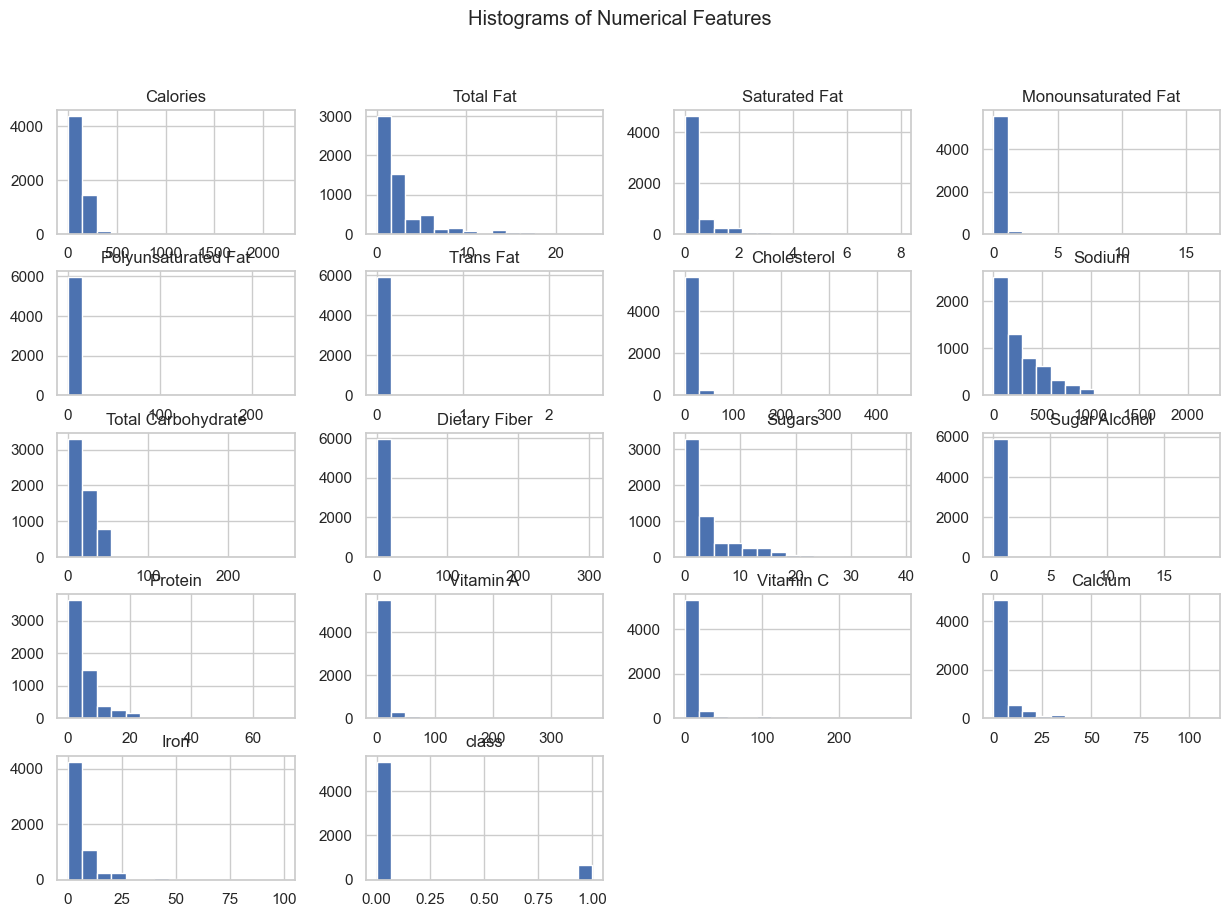

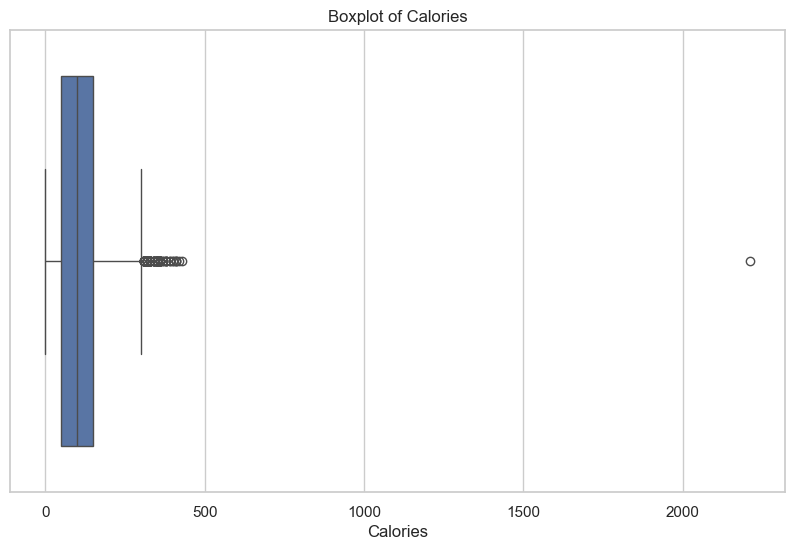

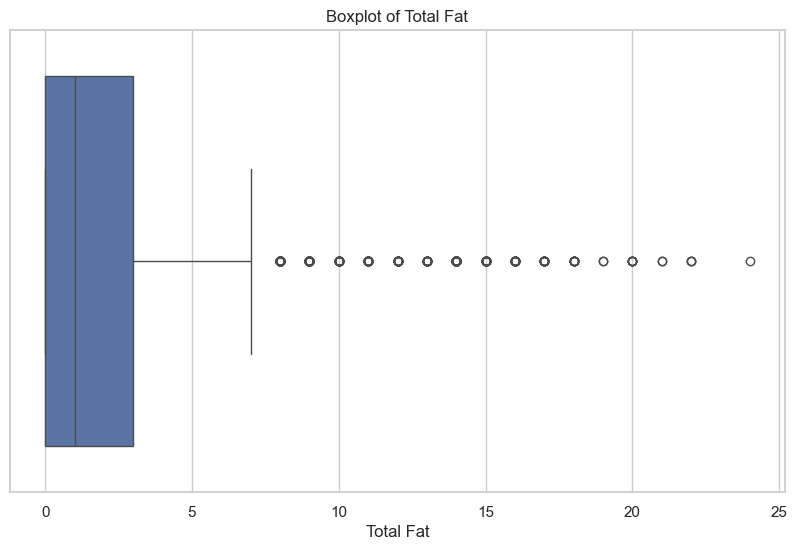

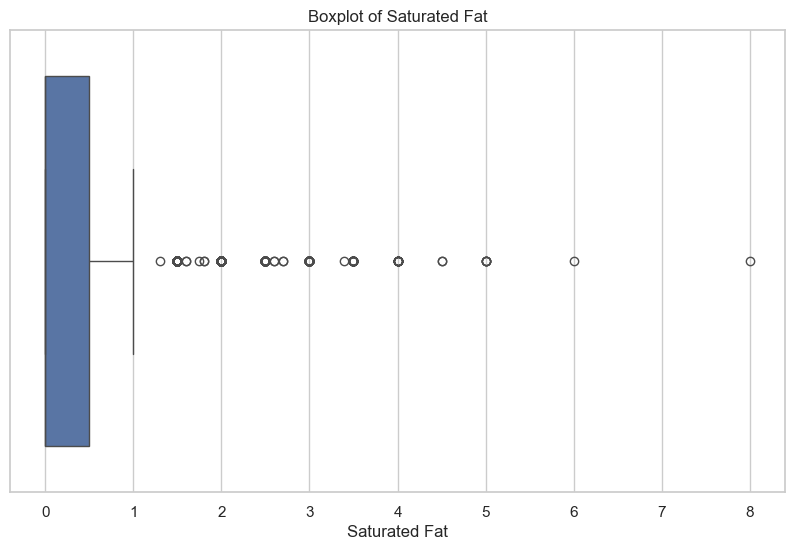

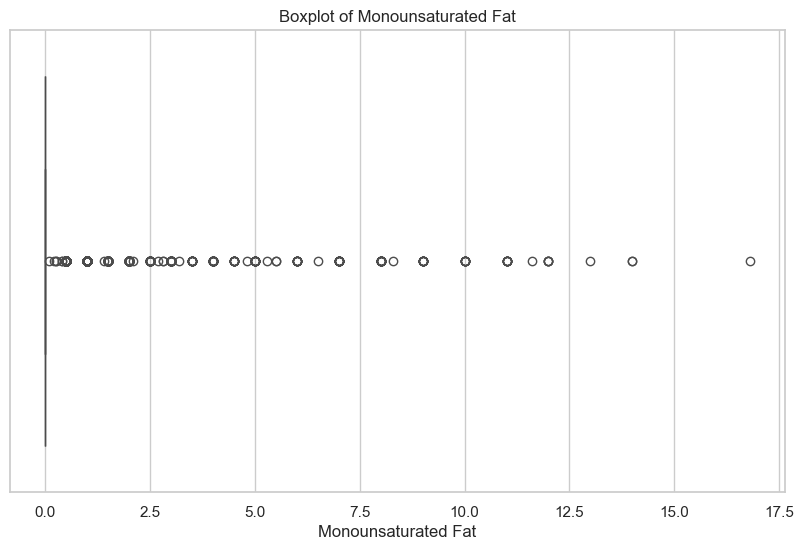

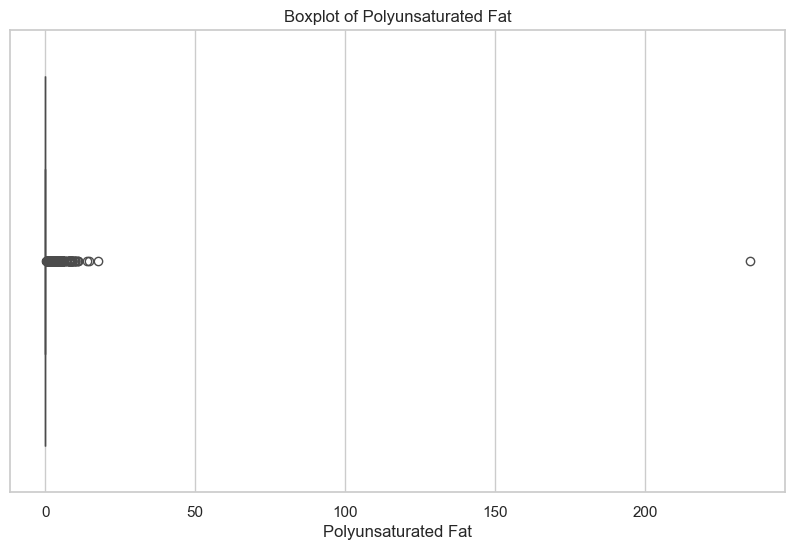

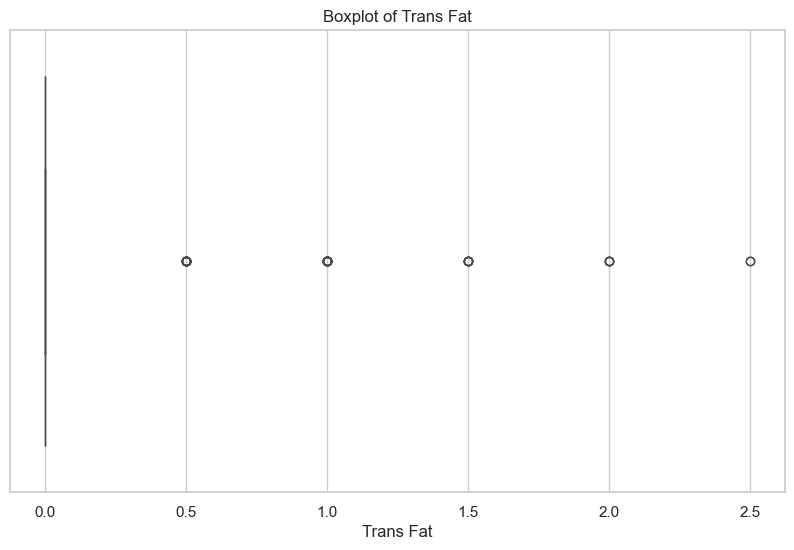

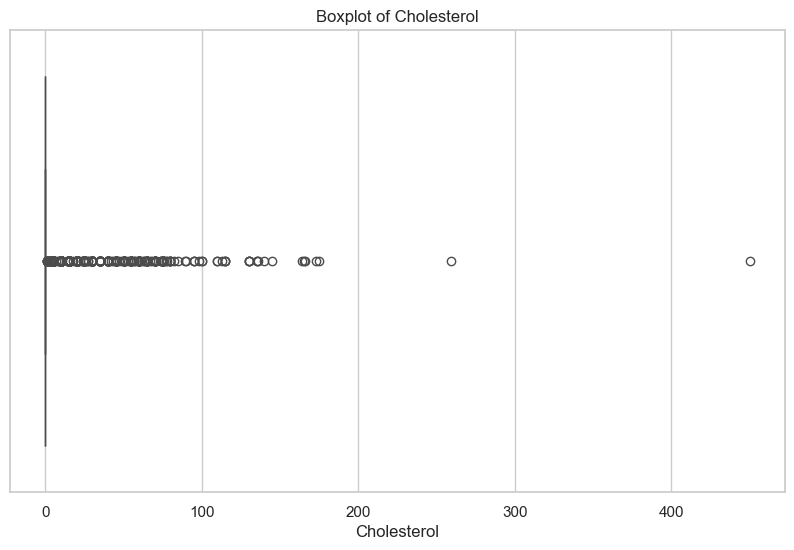

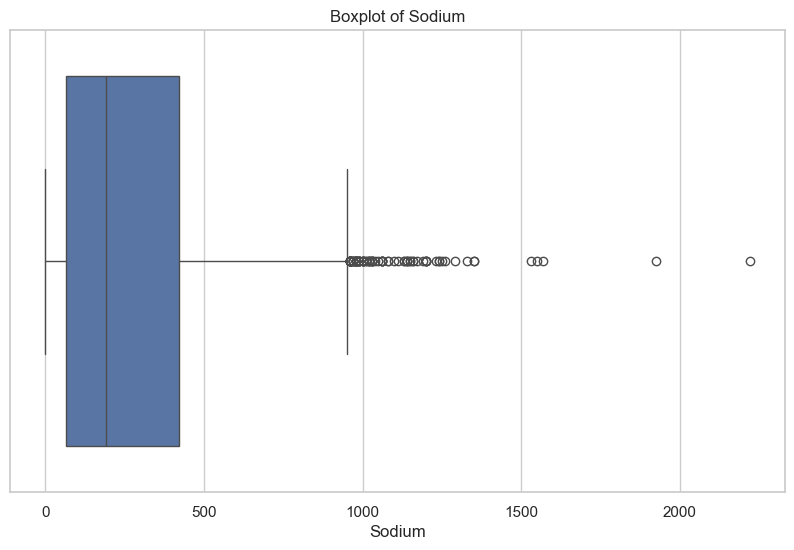

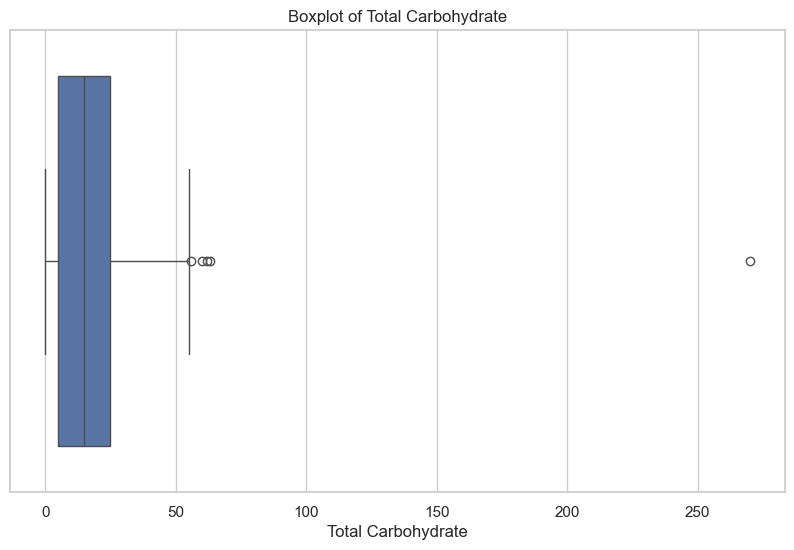

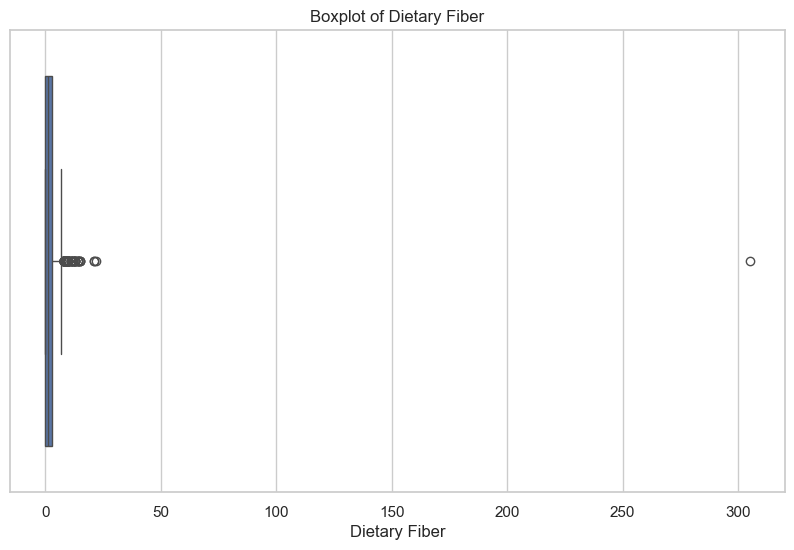

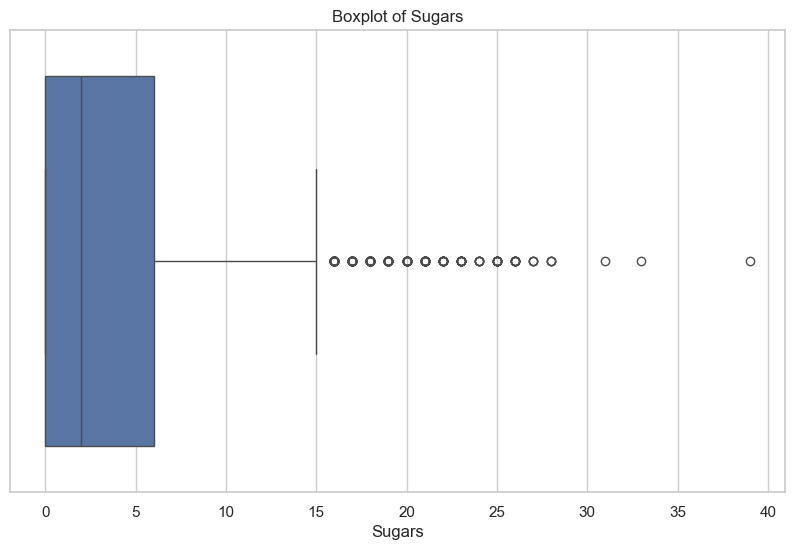

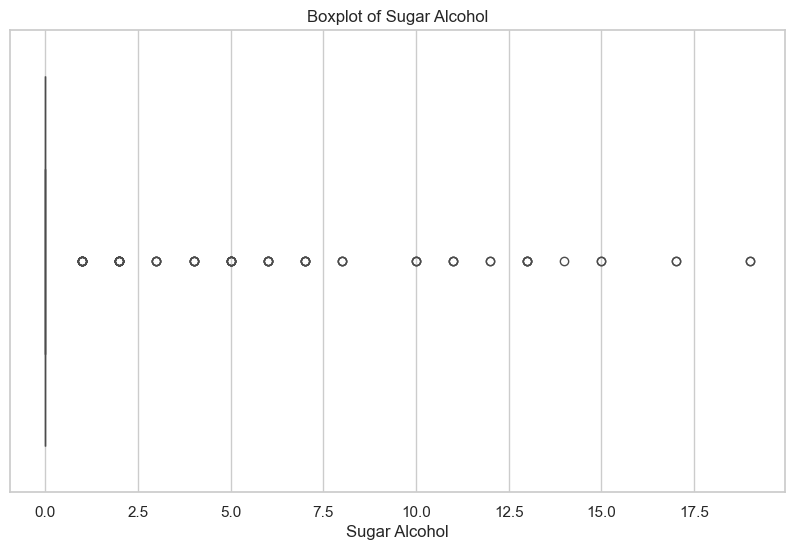

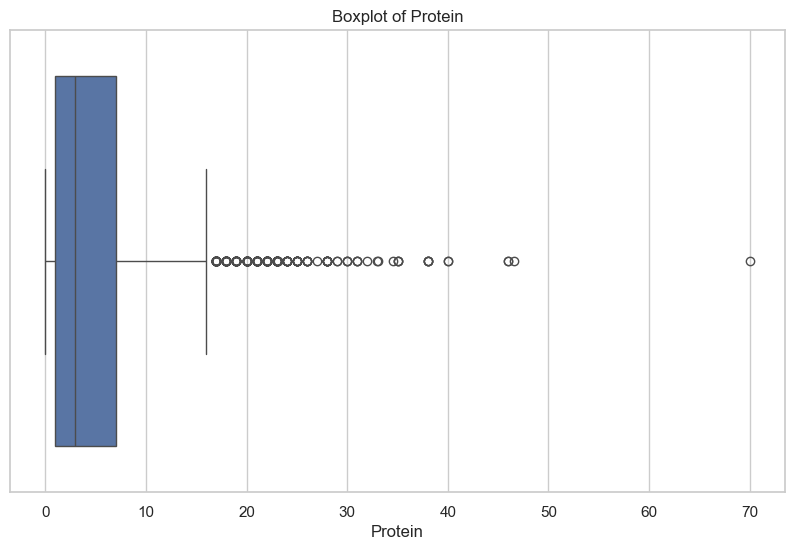

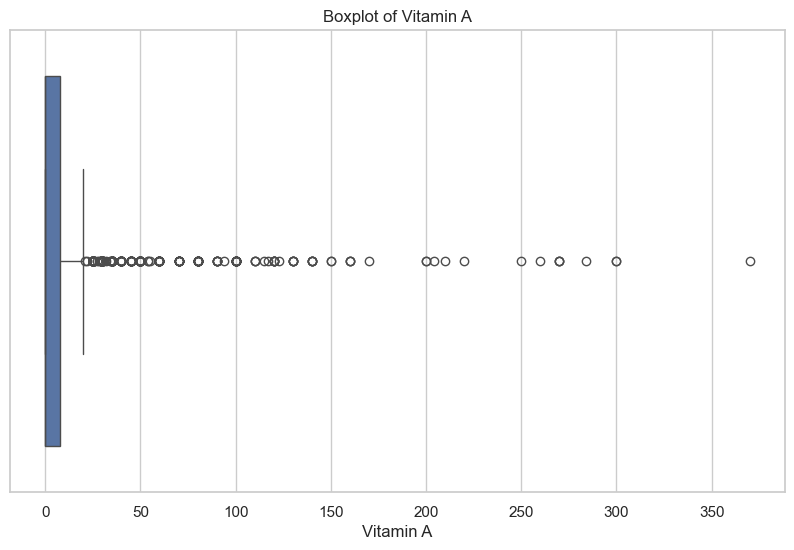

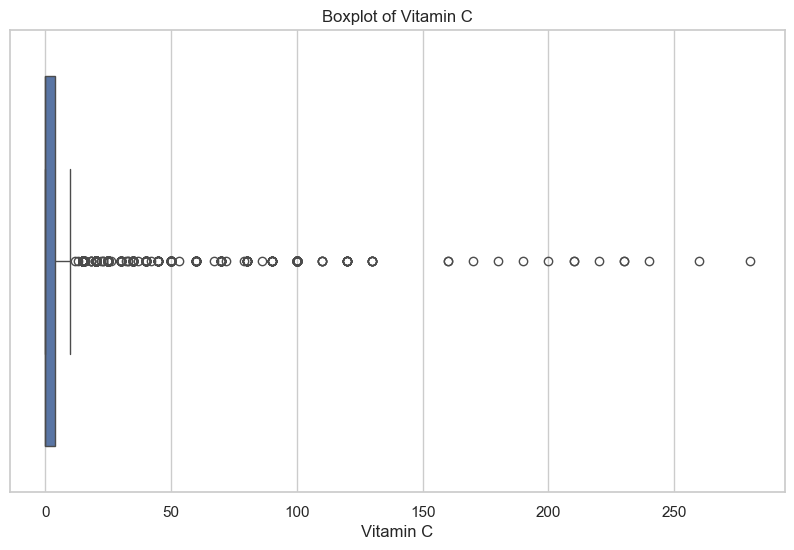

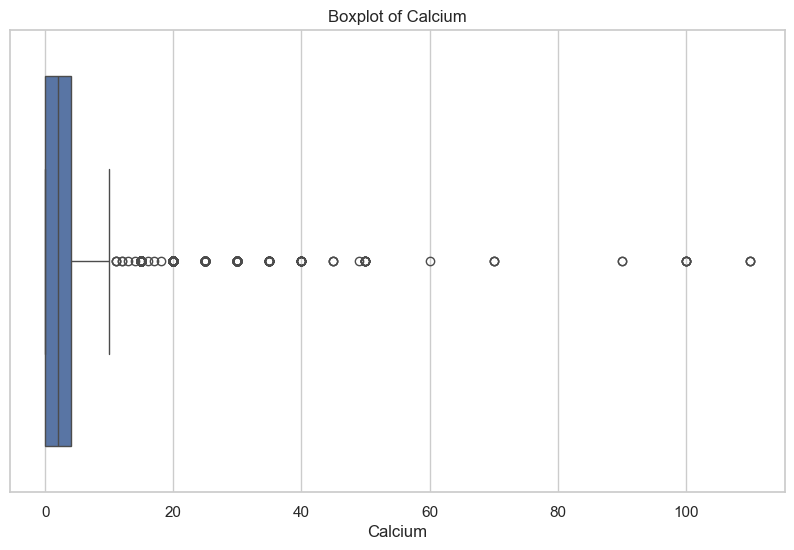

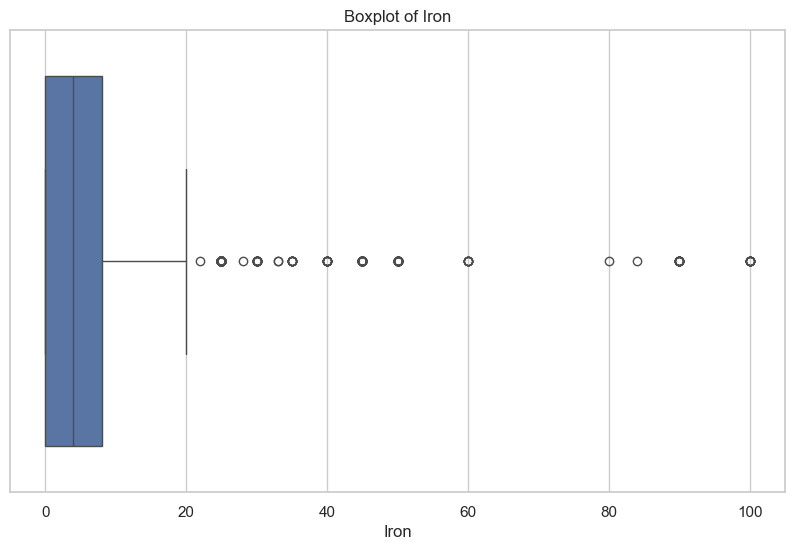

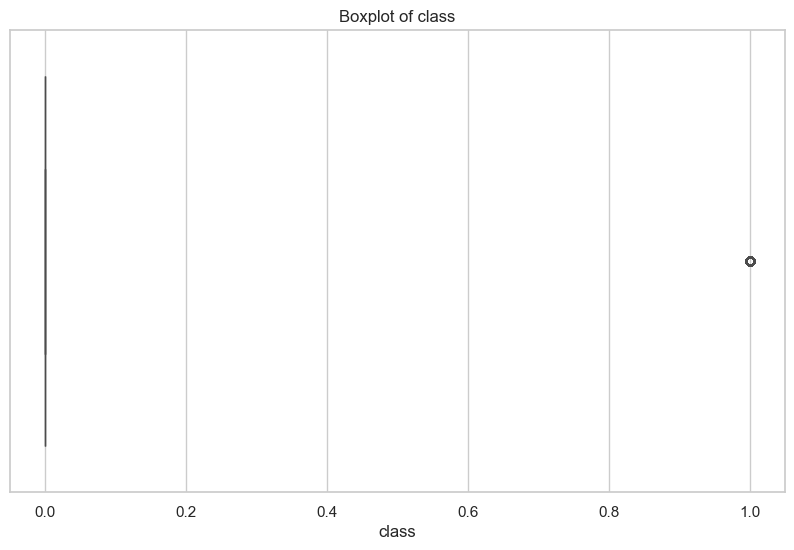

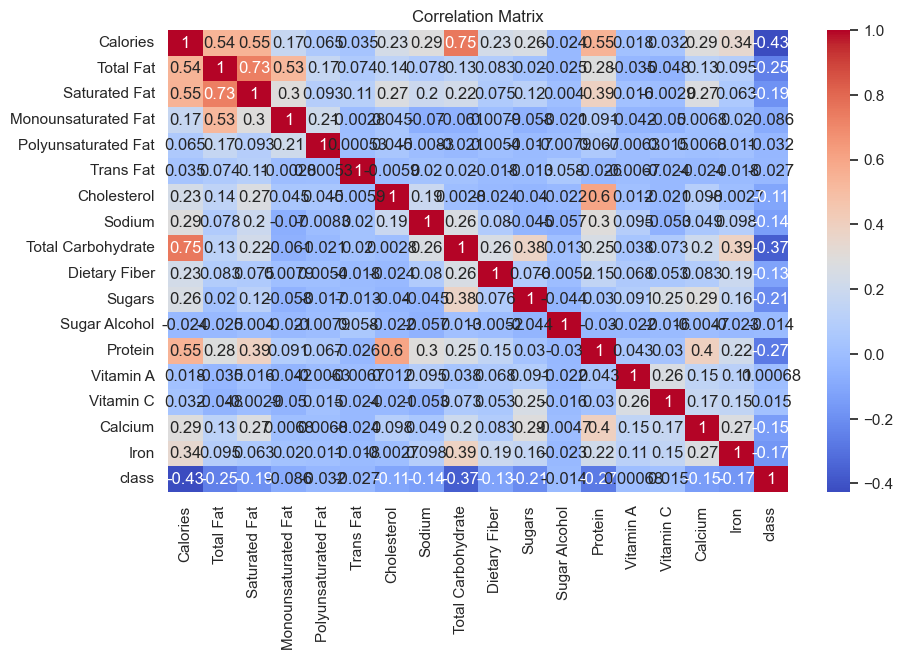

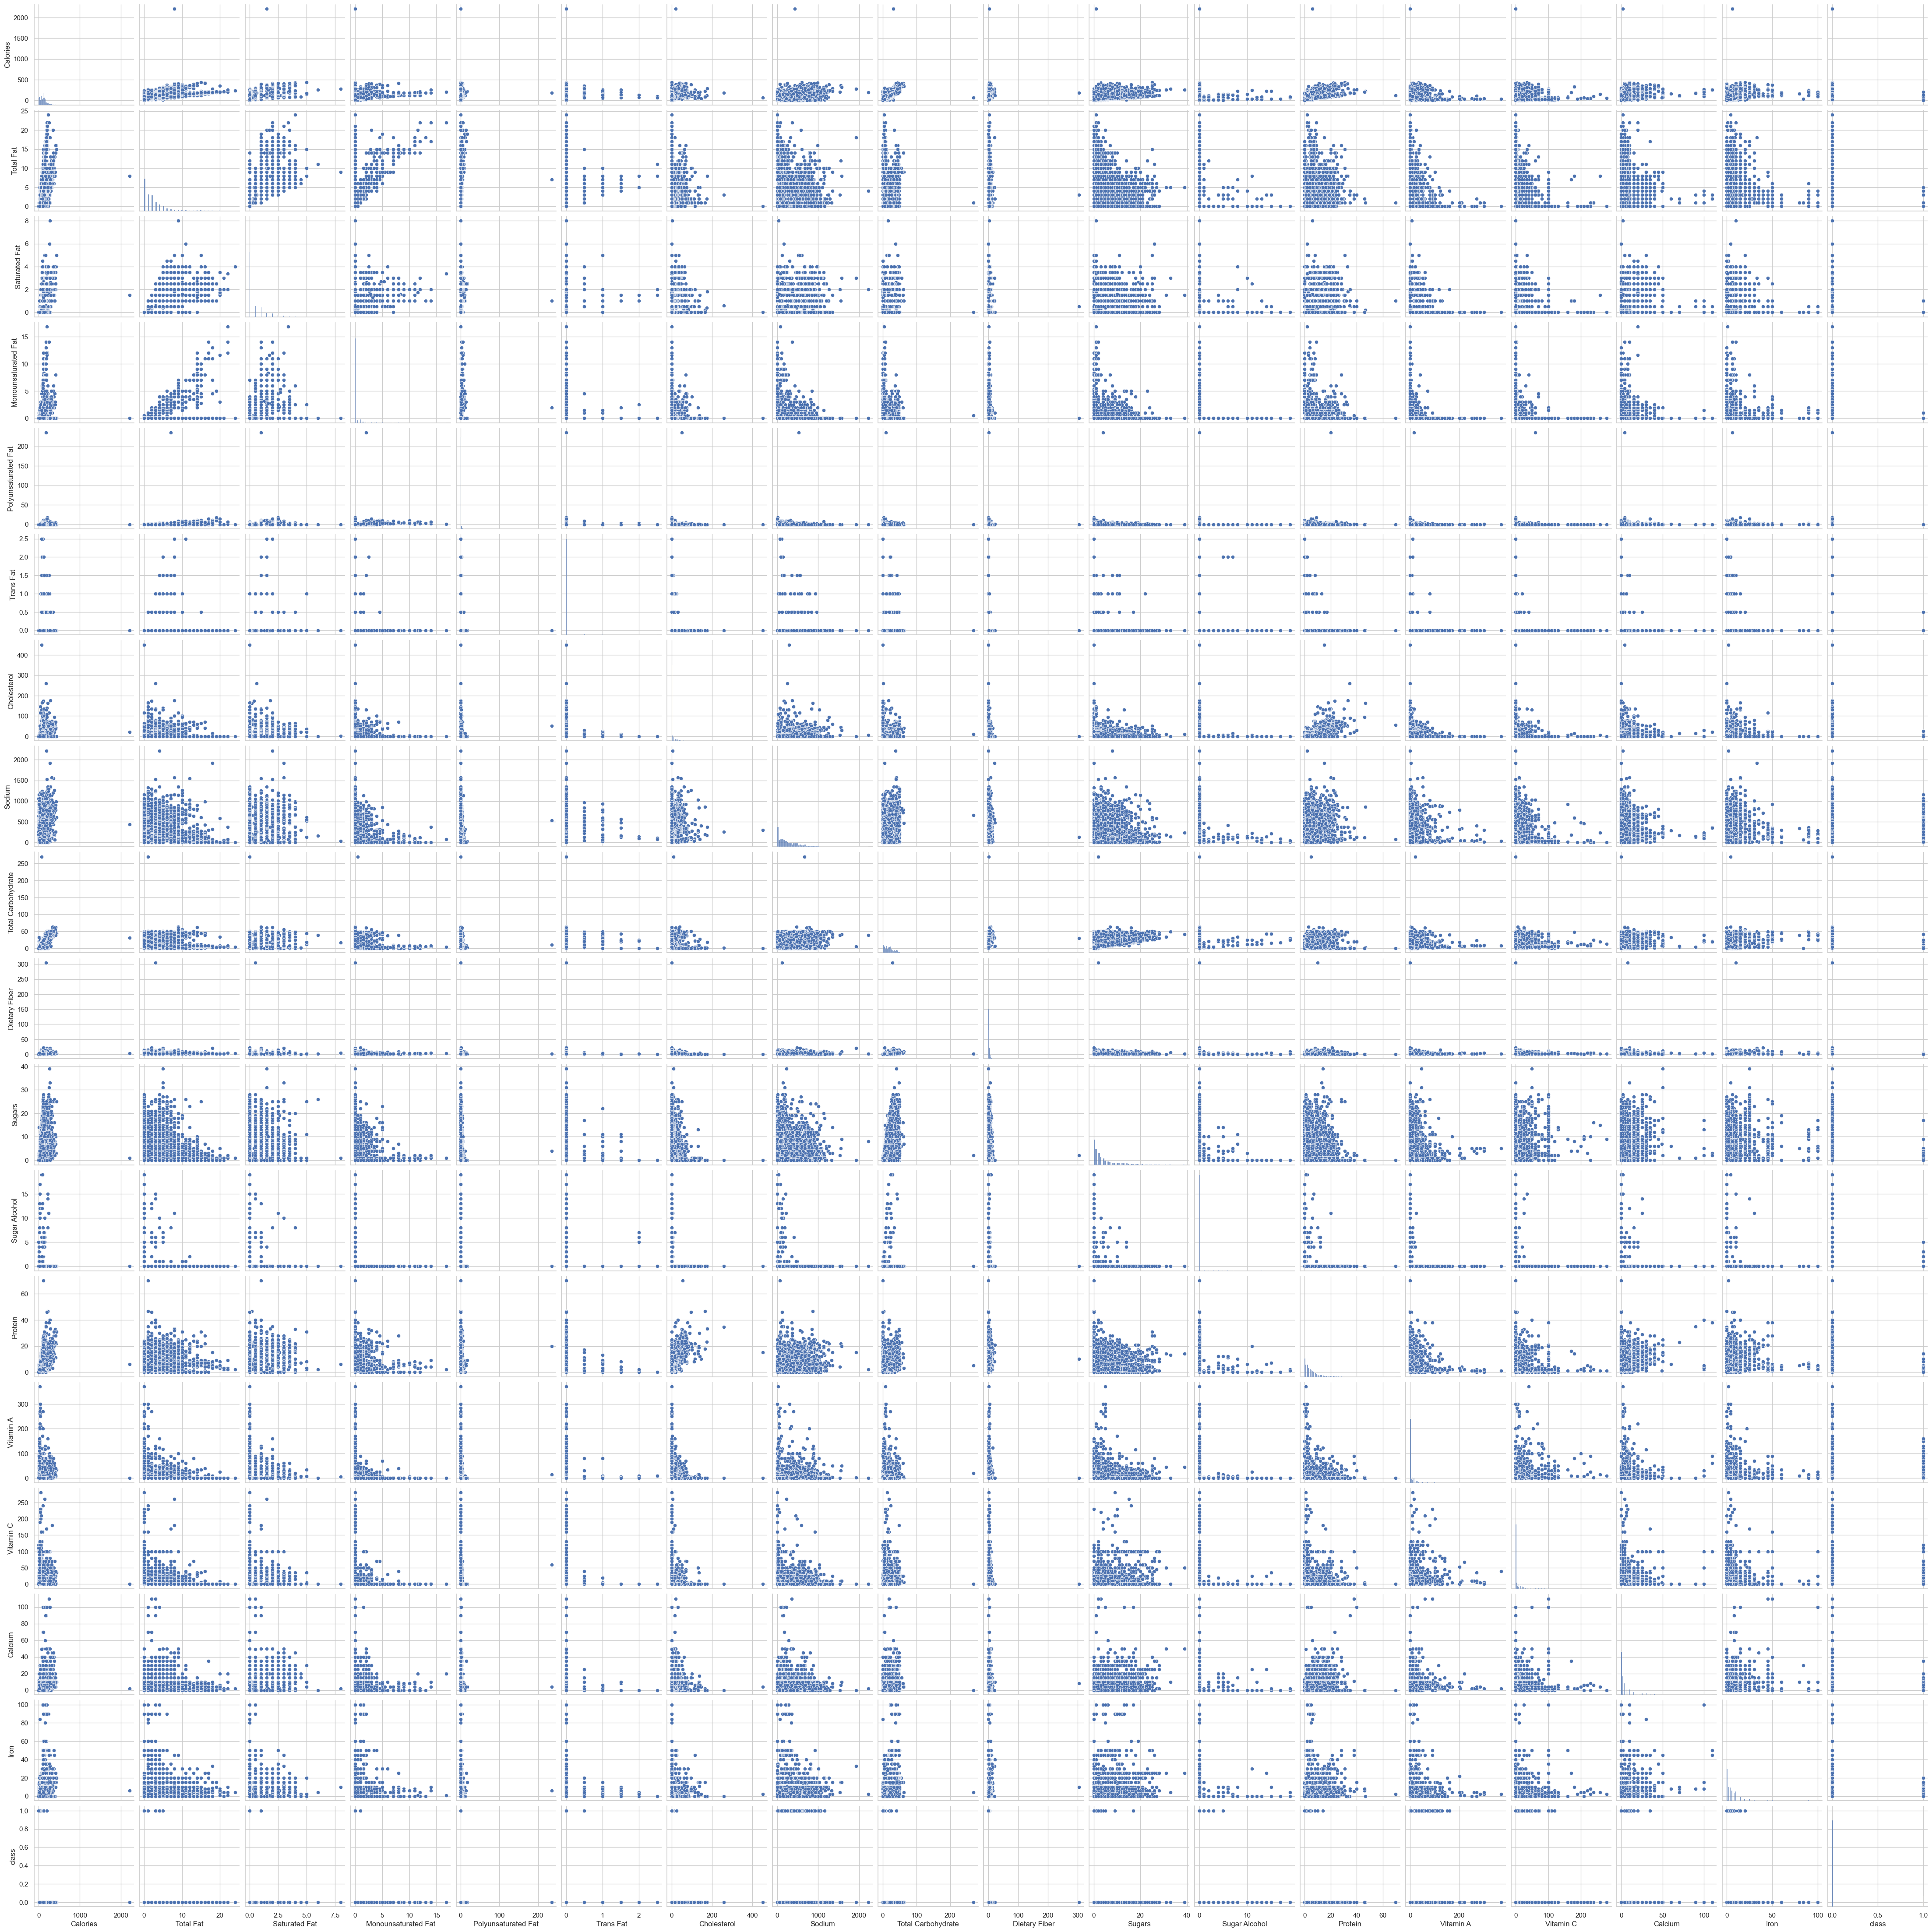

In [10]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ===============================
# 2. LOAD DATASET
# ===============================
# Replace with your file path
df = pd.read_csv("/Users/chaudhary/Downloads/food_items_binary.csv")# ===============================
# 3. BASIC INFO
# ===============================
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

# ===============================
# 4. MISSING VALUES
# ===============================
print("\nMissing Values:")
print(df.isnull().sum())

# Visualization of missing values
plt.figure()
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ===============================
# 5. DESCRIPTIVE STATISTICS
# ===============================
print("\nStatistical Summary:")
print(df.describe())

# ===============================
# 6. DUPLICATES
# ===============================
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates if needed
df = df.drop_duplicates()

# ===============================
# 7. NUMERICAL FEATURES ANALYSIS
# ===============================
num_cols = df.select_dtypes(include=np.number).columns

# Histograms
df[num_cols].hist(bins=15, figsize=(15,10))
plt.suptitle("Histograms of Numerical Features")
plt.show()

# Boxplots (outliers detection)
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ===============================
# 8. CATEGORICAL FEATURES
# ===============================
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# ===============================
# 9. CORRELATION ANALYSIS
# ===============================
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ===============================
# 10. PAIRPLOT (optional but powerful)
# ===============================
sns.pairplot(df)
plt.show()

# ===============================
# 11. TARGET VARIABLE ANALYSIS (if exists)
# ===============================
# Replace 'target' with your column name
if 'target' in df.columns:
    plt.figure()
    sns.countplot(x=df['target'])
    plt.title("Target Variable Distribution")
    plt.show()

    # Correlation with target
    print("\nCorrelation with Target:")
    print(df.corr(numeric_only=True)['target'].sort_values(ascending=False))

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Features & Target
X = df.drop("class", axis=1)
y = df["class"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9698492462311558

Confusion Matrix:
[[1047   18]
 [  18  111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1065
           1       0.86      0.86      0.86       129

    accuracy                           0.97      1194
   macro avg       0.92      0.92      0.92      1194
weighted avg       0.97      0.97      0.97      1194



Accuracy: 0.9556113902847572

Confusion Matrix:
[[1032   33]
 [  20  109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1065
           1       0.77      0.84      0.80       129

    accuracy                           0.96      1194
   macro avg       0.87      0.91      0.89      1194
weighted avg       0.96      0.96      0.96      1194



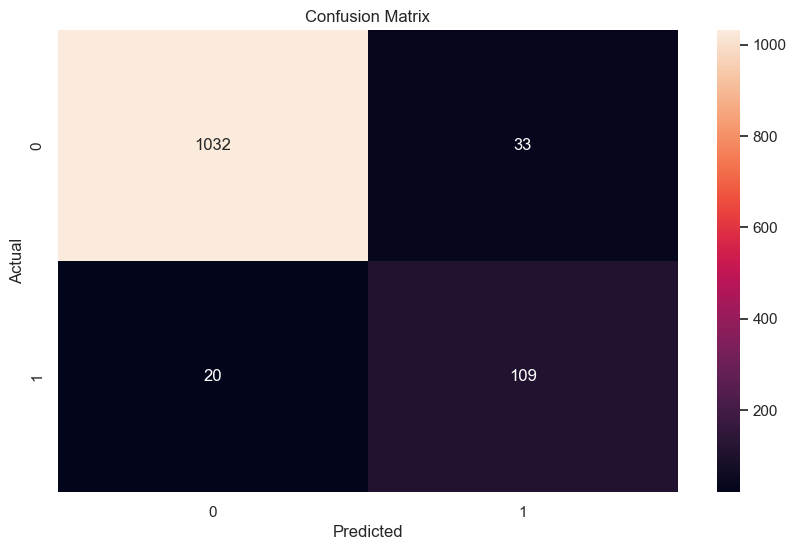

In [13]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. DEFINE FEATURES & TARGET
# ===============================
X = df.drop("class", axis=1)
y = df["class"]

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. FEATURE SCALING (VERY IMPORTANT for SVM)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 5. TRAIN SVM MODEL
# ===============================
model = SVC(kernel='linear')   # you can try 'rbf' also
model.fit(X_train, y_train)

# ===============================
# 6. PREDICTIONS
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 7. EVALUATION
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 8. CONFUSION MATRIX VISUALIZATION
# ===============================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.964824120603015

Confusion Matrix:
[[1039   26]
 [  16  113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1065
           1       0.81      0.88      0.84       129

    accuracy                           0.96      1194
   macro avg       0.90      0.93      0.91      1194
weighted avg       0.97      0.96      0.97      1194



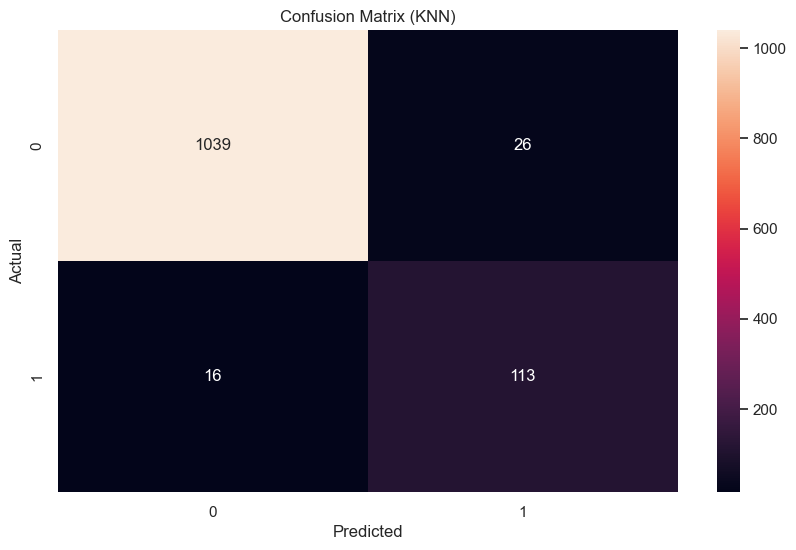

In [14]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. DEFINE FEATURES & TARGET
# ===============================
X = df.drop("class", axis=1)
y = df["class"]

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. FEATURE SCALING (VERY IMPORTANT for KNN)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 5. TRAIN KNN MODEL
# ===============================
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# ===============================
# 6. PREDICTIONS
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 7. EVALUATION
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 8. CONFUSION MATRIX VISUALIZATION
# ===============================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.9505862646566164

Confusion Matrix:
[[1033   32]
 [  27  102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1065
           1       0.76      0.79      0.78       129

    accuracy                           0.95      1194
   macro avg       0.87      0.88      0.87      1194
weighted avg       0.95      0.95      0.95      1194



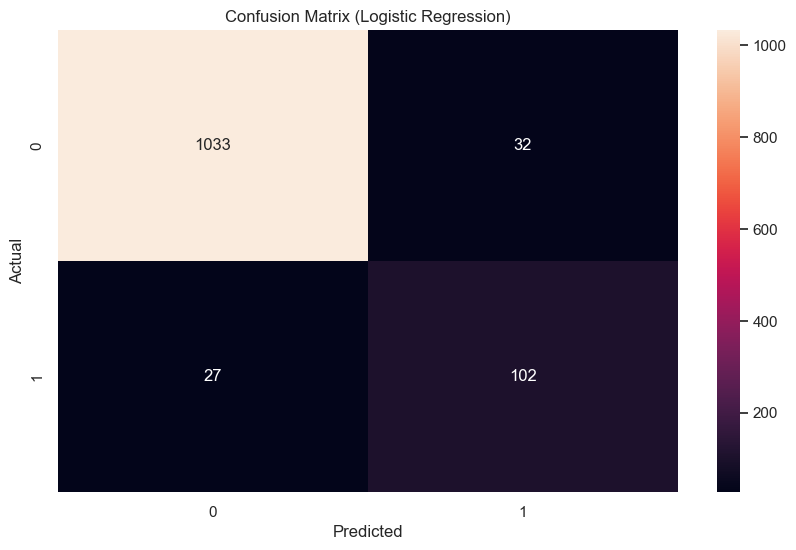

In [15]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2. DEFINE FEATURES & TARGET
# ===============================
X = df.drop("class", axis=1)
y = df["class"]

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. FEATURE SCALING (IMPORTANT)
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 5. TRAIN LOGISTIC REGRESSION MODEL
# ===============================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ===============================
# 6. PREDICTIONS
# ===============================
y_pred = model.predict(X_test)

# ===============================
# 7. EVALUATION
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===============================
# 8. CONFUSION MATRIX VISUALIZATION
# ===============================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Accuracy: 0.9698
SVM Accuracy: 0.9514
KNN Accuracy: 0.9648
Logistic Regression Accuracy: 0.9506

Comparison Table:
                  Model  Accuracy
0        Decision Tree  0.969849
1                  SVM  0.951424
2                  KNN  0.964824
3  Logistic Regression  0.950586


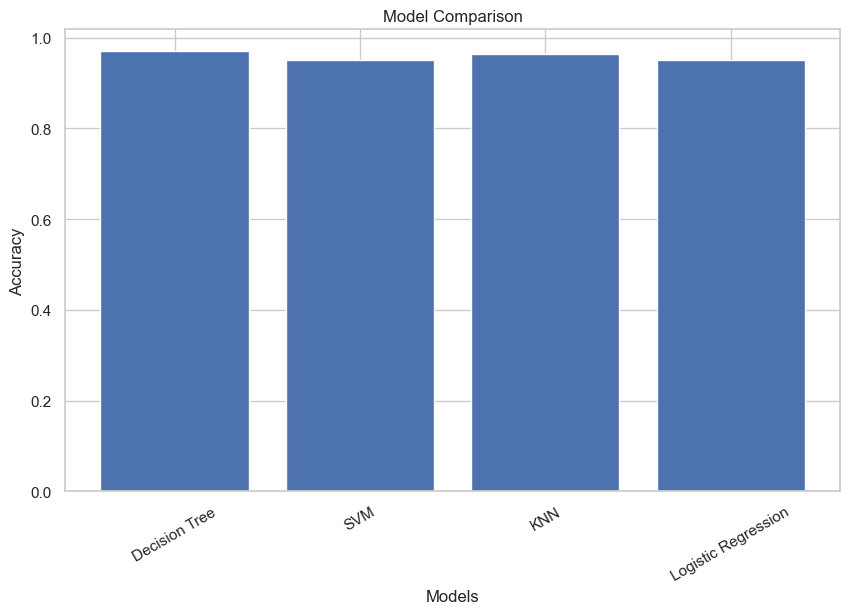

In [16]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 2. DEFINE FEATURES & TARGET
# ===============================
X = df.drop("class", axis=1)
y = df["class"]

# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 4. SCALING (for SVM, KNN, Logistic)
# ===============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 5. INITIALIZE MODELS
# ===============================
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

# ===============================
# 6. TRAIN & EVALUATE
# ===============================
results = {}

for name, model in models.items():
    
    # Use scaled data for some models
    if name in ["SVM", "KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# ===============================
# 7. RESULT TABLE
# ===============================
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\nComparison Table:\n", results_df)

# ===============================
# 8. VISUALIZATION
# ===============================
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()